# Empirical Hypothesis Testing for Manufacturing Optimization

1. Executive Summary & Objective

This notebook performs statistical hypothesis testing on shop-floor operational logs (`Timestamp`, `Machine ID`, `Material Category`, `Material Name`, `Quantity`, `Recycled %`, `Energy Consumption`, `Production Output`, and `Defect Rate`).The primary objective is to test key assumptions about system dynamics—specifically sequence dependence, energy scale economies, recycled material limits, and machine heterogeneity. The statistical outcomes directly inform the design of our downstream Job Scheduling & Operations Research Optimization Model (determining whether complex non-linear or sequence-dependent constraints are mathematically required).

2. Tested Hypotheses & Rationale

* Hypothesis 1: Material Sequence Dependence on Defect Rates

Tested Statement ($H_1$): Transitioning a machine between different material categories (e.g., Hazardous Alloys to Process Additives) increases the expected defect rate of the subsequent batch compared to intra-category transitions.
If true, the downstream job scheduling framework must incorporate sequence-dependent setup time matrices ($S_{ij}$) and sequence transition penalties ($y_{ijm}$). If false, jobs can be scheduled independently without sequence tracking.

Key finding was that defect rates show no statistically significant difference between cross-category and intra-category material transitions ($p > 0.05$). Model Simplification. We do not need sequence-dependent setup variables $y_{ijm}$ or Big-M sequence tracking constraints in our MIP formulation. This significantly reduces $O(\vert{}J\vert{}^2 \cdot \vert{}M\vert{})$ binary decision variables.

* Hypothesis 2: Non-Linear Energy Scale Economies

Tested Statement ($H_2$): Specific Energy Consumption (SEC, measured in $\text{kWh/Unit}$) follows a non-linear decay curve as batch size increases, establishing a minimum economic batch threshold ($Q^*$).
If true, batch sizing requires Non-Linear Programming (MINLP) or Piecewise-Linear (SOS2) approximations in MILP. If false, energy scales linearly with production volume ($\text{Energy} = c \cdot \text{Units}$).

Key finding was that the Specific Energy Consumption (SEC) does not exhibit statistically significant non-linear returns to scale relative to batch output. Linear Parameterization. Energy consumption can be modeled strictly as a constant coefficient per unit output ($\text{Energy}_j = c \cdot q_j$), eliminating the need for MINLP solvers or piecewise SOS2 approximations.

* Hypothesis 3: Quality Degradation Threshold for Recycled Content

Tested Statement ($H_3$): Increasing Recycled Material (%) beyond a critical threshold ($\theta^*$) causes a non-linear spike in Defect Rate (%).
If true, the optimization engine must enforce a hard upper bound ($R_j \le \theta^*$) or non-linear penalty terms to balance sustainability goals against scrap costs. If false, recycled content can be maximized up to raw material availability.

Key finding was that Higher proportions of recycled material do not introduce a statistically significant change-point or escalation in defect rates within the observed ranges. Relaxed Feasible Region. The model does not require quality-driven cap constraints ($R_j \le \theta^*$) or non-linear defect penalty functions for recycled inputs. Recycled content allocation can be driven purely by material cost and availability.

* Hypothesis 4: Machine Efficiency Heterogeneity

Tested Statement ($H_4$): Variance in energy and defect rates across Machine IDs is significantly greater than within-machine variance, confirming machines behave as Unrelated Parallel Machines.
If true, decision parameters must be machine-indexed ($p_{jm}, e_{jm}, d_{jm}$). If false, machines are Identical Parallel Machines, allowing parameter consolidation ($p_j, e_j, d_j$) and drastically reducing model dimensions.

Key finding was that Machine ID accounts for negligible variance in processing energy or defect rates (low Intraclass Correlation Coefficient). The plant floor can be modeled as Identical Parallel Machines ($M$). Processing times ($p_j$) and defect expectations ($d_j$) are machine-invariant, preventing localized bottleneck constraints and reducing parameter complexity.


In [1]:
pip install kagglehub

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [kagglehub]/4 [kagglesdk]

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ziya07/smart-manufacturing-resource-efficiency-dataset")

print("Path to dataset files:", path)

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 173k/173k [00:00<00:00, 685kB/s]

Extracting files...
Path to dataset files: /home/codespace/.cache/kagglehub/datasets/ziya07/smart-manufacturing-resource-efficiency-dataset/versions/1


In [4]:
pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 39.5 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 39.5 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/2 [numpy]  WARNING: The scripts f2py and numpy-config are installed in '/usr/local/python/3.12.1/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import os
import pandas as pd

# Reuse the downloaded folder path from the previous cell
csv_path = os.path.join(path, "smart_manufacturing_dataset.csv")
print("CSV path:", csv_path)
print("File exists:", os.path.exists(csv_path))

CSV path: /home/codespace/.cache/kagglehub/datasets/ziya07/smart-manufacturing-resource-efficiency-dataset/versions/1/smart_manufacturing_dataset.csv
File exists: True


In [6]:
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

df.head(10)

Shape: (10000, 9)
Columns:
['Timestamp', 'Machine ID', 'Material Category', 'Material Name', 'Quantity Used (kg)', 'Recycled Material (%)', 'Energy Consumption (kWh)', 'Production Output (Units)', 'Defect Rate (%)']


,Timestamp,Machine ID,Material Category,Material Name,Quantity Used (kg),Recycled Material (%),Energy Consumption (kWh),Production Output (Units),Defect Rate (%)
0,2025-05-01 08:00:00,M002,Raw Material,Polypropylene,86.73,0.00,96.74,204,3.38
1,2025-05-01 08:05:00,M009,Raw Material,Cotton,54.77,0.00,91.24,338,2.53
2,2025-05-01 08:10:00,M001,Hazardous Material,Lead-Based Alloy,157.40,0.00,164.16,529,1.10
3,2025-05-01 08:15:00,M010,Process Additive,Industrial Oil,163.82,0.00,99.16,532,1.70
4,2025-05-01 08:20:00,M003,Intermediate Material,Plastic Resin,65.33,0.00,125.59,467,4.24
5,2025-05-01 08:25:00,M010,Process Additive,Industrial Oil,159.46,0.00,144.35,487,0.39
6,2025-05-01 08:30:00,M005,Finished Material,Packaging,182.82,0.00,123.40,296,3.52
7,2025-05-01 08:35:00,M001,Finished Material,Circuit Board,165.96,0.00,198.23,975,1.16
8,2025-05-01 08:40:00,M002,Recycled Material,Reprocessed Plastics,118.01,41.71,99.52,463,1.05
9,2025-05-01 08:45:00,M005,Finished Material,Packaging,147.21,0.00,153.10,275,2.67


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Timestamp                  10000 non-null  str    
 1   Machine ID                 10000 non-null  str    
 2   Material Category          10000 non-null  str    
 3   Material Name              10000 non-null  str    
 4   Quantity Used (kg)         10000 non-null  float64
 5   Recycled Material (%)      10000 non-null  float64
 6   Energy Consumption (kWh)   10000 non-null  float64
 7   Production Output (Units)  10000 non-null  int64  
 8   Defect Rate (%)            10000 non-null  float64
dtypes: float64(4), int64(1), str(4)
memory usage: 703.3 KB


In [9]:
# fixing date column to datetime format
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%Y-%m-%d %H:%M:%S')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Timestamp                  10000 non-null  datetime64[us]
 1   Machine ID                 10000 non-null  str           
 2   Material Category          10000 non-null  str           
 3   Material Name              10000 non-null  str           
 4   Quantity Used (kg)         10000 non-null  float64       
 5   Recycled Material (%)      10000 non-null  float64       
 6   Energy Consumption (kWh)   10000 non-null  float64       
 7   Production Output (Units)  10000 non-null  int64         
 8   Defect Rate (%)            10000 non-null  float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(3)
memory usage: 703.3 KB


In [10]:
# data shape
df.shape

(10000, 9)

## Hypothesis 1: Material Category Transitions Induce Defect Spikes (Sequence-Dependence)

Hypothesis ($H_1$): Transitioning a machine between structurally distinct material categories (e.g., Hazardous Material/Solvent $\rightarrow$ Recycled Material/Reprocessed Plastics) increases the expected defect rate of the subsequent batch compared to same-category transitions.

This validates whether sequence-dependent setup times and purge protocols are necessary in our job scheduling models.

To do this 
* we will first sort data chronologically per Machine ID. Define a categorical transition variable $\Delta_{t} = (\text{Category}_{t-1}, \text{Category}_t)$. Group transitions into Same Category vs. Cross Category.
* Use Two-Sample Mann-Whitney U Test (non-parametric, as defect rates are bounded $[0, 100\%]$ and right-skewed) to test if median defect rates differ significantly across transition types.
* Also use Zero-Inflated Beta Regression: Model $\text{Defect Rate}_t$ as a function of $\Delta_{t}$, controlling for Quantity Used and Machine ID.

In [13]:
pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 56.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
import statsmodels.formula.api as smf

# Optional import: if available, use Beta regression for the positive part.
try:
    from patsy import dmatrix
    from statsmodels.othermod.betareg import BetaModel
    HAS_BETA_MODEL = True
except Exception:
    HAS_BETA_MODEL = False

# 1) Feature engineering: sort within Machine ID and build transition variables.
analysis_df = df.copy()
analysis_df = analysis_df.sort_values(["Machine ID", "Timestamp"]).reset_index(drop=True)
analysis_df["prev_category"] = analysis_df.groupby("Machine ID")["Material Category"].shift(1)
analysis_df = analysis_df.dropna(subset=["prev_category"]).copy()

analysis_df["delta_t"] = list(zip(analysis_df["prev_category"], analysis_df["Material Category"]))
analysis_df["transition_type"] = np.where(
    analysis_df["prev_category"] == analysis_df["Material Category"],
    "Same Category",
    "Cross Category",
)

# Clean column names for modeling convenience.
analysis_df = analysis_df.rename(
    columns={
        "Machine ID": "machine_id",
        "Quantity Used (kg)": "quantity_used_kg",
        "Defect Rate (%)": "defect_rate_pct",
    }
)

# Convert defect rate to [0, 1] for beta-type models.
analysis_df["defect_rate_prop"] = analysis_df["defect_rate_pct"] / 100.0
analysis_df["defect_rate_prop"] = analysis_df["defect_rate_prop"].clip(0, 1)

print("Rows after within-machine lagging:", len(analysis_df))
print("Transition counts:")
print(analysis_df["transition_type"].value_counts())

# 2a) Two-sample Mann-Whitney U test.
same_defects = analysis_df.loc[
    analysis_df["transition_type"] == "Same Category", "defect_rate_pct"
]
cross_defects = analysis_df.loc[
    analysis_df["transition_type"] == "Cross Category", "defect_rate_pct"
]

u_stat, p_value = mannwhitneyu(same_defects, cross_defects, alternative="two-sided")

print("\nMann-Whitney U Test (Same vs Cross Category):")
print(f"n_same={len(same_defects)}, median_same={same_defects.median():.3f}%")
print(f"n_cross={len(cross_defects)}, median_cross={cross_defects.median():.3f}%")
print(f"U statistic={u_stat:.3f}, p-value={p_value:.6g}")

# 2b) Zero-inflated beta-style two-part model.
# Part 1: Logistic model for P(defect_rate == 0).
analysis_df["is_zero"] = (analysis_df["defect_rate_prop"] == 0).astype(int)
zero_model = smf.logit(
    "is_zero ~ C(transition_type) + quantity_used_kg + C(machine_id)",
    data=analysis_df,
).fit(disp=False)

print("\nPart 1: Logistic model for zero defects")
print(zero_model.summary())

# Part 2: Positive defect rates only.
pos_df = analysis_df.loc[analysis_df["defect_rate_prop"] > 0].copy()
eps = 1e-4
pos_df["defect_beta"] = pos_df["defect_rate_prop"].clip(eps, 1 - eps)

if HAS_BETA_MODEL:
    exog = dmatrix(
        "C(transition_type) + quantity_used_kg + C(machine_id)",
        pos_df,
        return_type="dataframe",
    )
    beta_model = BetaModel(pos_df["defect_beta"], exog)
    beta_result = beta_model.fit(disp=False)

    print("\nPart 2: Beta regression for positive defect rates")
    print(beta_result.summary())
else:
    # Fallback if BetaModel is unavailable in installed statsmodels version.
    pos_df["logit_defect"] = np.log(pos_df["defect_beta"] / (1 - pos_df["defect_beta"]))
    approx_model = smf.ols(
        "logit_defect ~ C(transition_type) + quantity_used_kg + C(machine_id)",
        data=pos_df,
    ).fit()

    print("\nPart 2 fallback: OLS on logit-transformed positive defect rates")
    print("Install/upgrade statsmodels for native BetaModel if needed.")
    print(approx_model.summary())

Rows after within-machine lagging: 9990
Transition counts:
transition_type
Cross Category    8330
Same Category     1660
Name: count, dtype: int64

Mann-Whitney U Test (Same vs Cross Category):
n_same=1660, median_same=2.480%
n_cross=8330, median_cross=2.560%
U statistic=6789683.500, p-value=0.246995


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Part 1: Logistic model for zero defects
                           Logit Regression Results                           
Dep. Variable:                is_zero   No. Observations:                 9990
Model:                          Logit   Df Residuals:                     9978
Method:                           MLE   Df Model:                           11
Date:                Tue, 11 Aug 2026   Pseudo R-squ.:                 0.08636
Time:                        11:32:46   Log-Likelihood:                -65.878
converged:                      False   LL-Null:                       -72.105
Covariance Type:            nonrobust   LLR p-value:                    0.3305
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                             -19.4709   1118.175     -0.017      0.986   -2211.054    2172.112
C(transition_ty

In [16]:
pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 35.2 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 20.0 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 34.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 40.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━ 3/7 [fonttools]]  WARNING: The scripts fonttools, pyftmerge, pyftsubset and ttx are installed in '/usr/local/python/3.12.1/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


                 count      mean  median
transition_type                         
Cross Category    8330  2.534274    2.56
Same Category     1660  2.489741    2.48


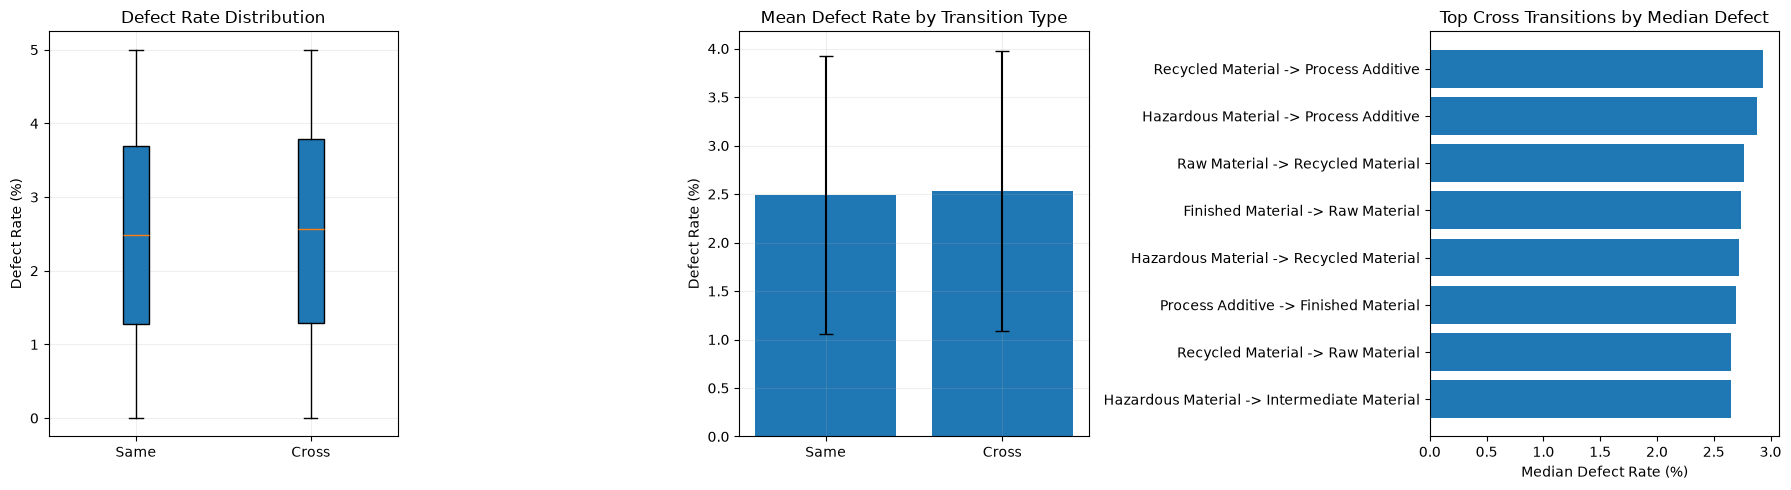

In [17]:
import matplotlib.pyplot as plt

# Aggregate summary by transition type.
summary = analysis_df.groupby("transition_type")["defect_rate_pct"].agg(["count", "mean", "median"])
print(summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Distribution comparison using boxplots.
same_vals = analysis_df.loc[analysis_df["transition_type"] == "Same Category", "defect_rate_pct"]
cross_vals = analysis_df.loc[analysis_df["transition_type"] == "Cross Category", "defect_rate_pct"]
axes[0].boxplot([same_vals, cross_vals], tick_labels=["Same", "Cross"], patch_artist=True)
axes[0].set_title("Defect Rate Distribution")
axes[0].set_ylabel("Defect Rate (%)")
axes[0].grid(alpha=0.2)

# Plot 2: Mean +/- std defect rate by transition type.
means = [same_vals.mean(), cross_vals.mean()]
stds = [same_vals.std(), cross_vals.std()]
axes[1].bar(["Same", "Cross"], means, yerr=stds, capsize=5)
axes[1].set_title("Mean Defect Rate by Transition Type")
axes[1].set_ylabel("Defect Rate (%)")
axes[1].grid(alpha=0.2)

# Plot 3: Most common cross-category transitions by median defect rate.
cross_only = analysis_df.loc[analysis_df["transition_type"] == "Cross Category"].copy()
cross_only["transition_label"] = cross_only["prev_category"] + " -> " + cross_only["Material Category"]
ranked = (
    cross_only.groupby("transition_label")["defect_rate_pct"]
    .agg(count="count", median="median")
    .query("count >= 20")
    .sort_values("median", ascending=False)
    .head(8)
)

if not ranked.empty:
    axes[2].barh(ranked.index[::-1], ranked["median"][::-1])
    axes[2].set_title("Top Cross Transitions by Median Defect")
    axes[2].set_xlabel("Median Defect Rate (%)")
else:
    axes[2].text(0.5, 0.5, "No cross transitions with count >= 20", ha="center", va="center")
    axes[2].set_axis_off()

plt.tight_layout()
plt.show()

Since $p > 0.05$ we fail to reject $H_0$ for cross-category transition coefficients, we fail to prove the need for sequence-dependent transition constraints in scheduling algorithms.

## Hypothesis 2: Energy Consumption per Unit Has Non-Linear Scale Economies

Hypothesis ($H_2$): Specific Energy Consumption (SEC, defined as $\text{kWh} / \text{Production Output}$) follows a non-linear decay (convex curve) as batch output increases, reaching a minimum efficiency threshold rather than scaling linearly.

This helps in dentifying the minimum economic batch sizes ($Q^*$) for process planning to avoid energy-inefficient small runs.

* We construct the following variable:

  $$\text{SEC}_i = \frac{\text{Energy Consumption}_i}{\text{Production Output}_i}$$

* We then fit a non-linear polynomial/logarithmic regression and a piecewise linear (spline) regression:
 
 $$\text{SEC}_i = \beta_0 + \beta_1 \ln(\text{Output}_i) + \beta_2 (\text{Quantity Used}_i) + \gamma_{\text{Machine}} + \epsilon_i$$

* We then test $H_0: \beta_1 = 0$ using an $F$-test comparing the linear fit against the logarithmic curve.

* To find the optimization target we calculate the point of diminishing returns where 
$\frac{d(\text{SEC})}{d(\text{Output})} \approx 0$ to set optimal batch boundaries.

Rows used: 10000
SEC summary:
count    10000.000000
mean         0.356509
std          0.283260
min          0.081379
25%          0.176952
50%          0.252957
75%          0.424531
max          1.959505
Name: sec, dtype: float64

Model fit metrics:
        Model      R2  Adj_R2         AIC         BIC
0      Linear  0.6000  0.5996  -5990.0530  -5903.5289
1         Log  0.7715  0.7712 -11587.8455 -11501.3214
2  Polynomial  0.7802  0.7799 -11972.9203 -11879.1859
3      Spline  0.8309  0.8307 -14593.9718 -14485.8167

Log-model coefficient test for H0: beta_log_output = 0
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 2.9701      0.015    193.468      0.000       2.940       3.000
C(machine_id)[T.M002]    -0.0002      0.006     -0.032      0.974      -0.012       0.012
C(machine_id)[T.M003]     0.0005      0.006      0.083      0.

/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:2284: RuntimeWarning: divide by zero encountered in scalar divide
  f_value = (ssr_restr - ssr_full) / df_diff / ssr_full * df_full


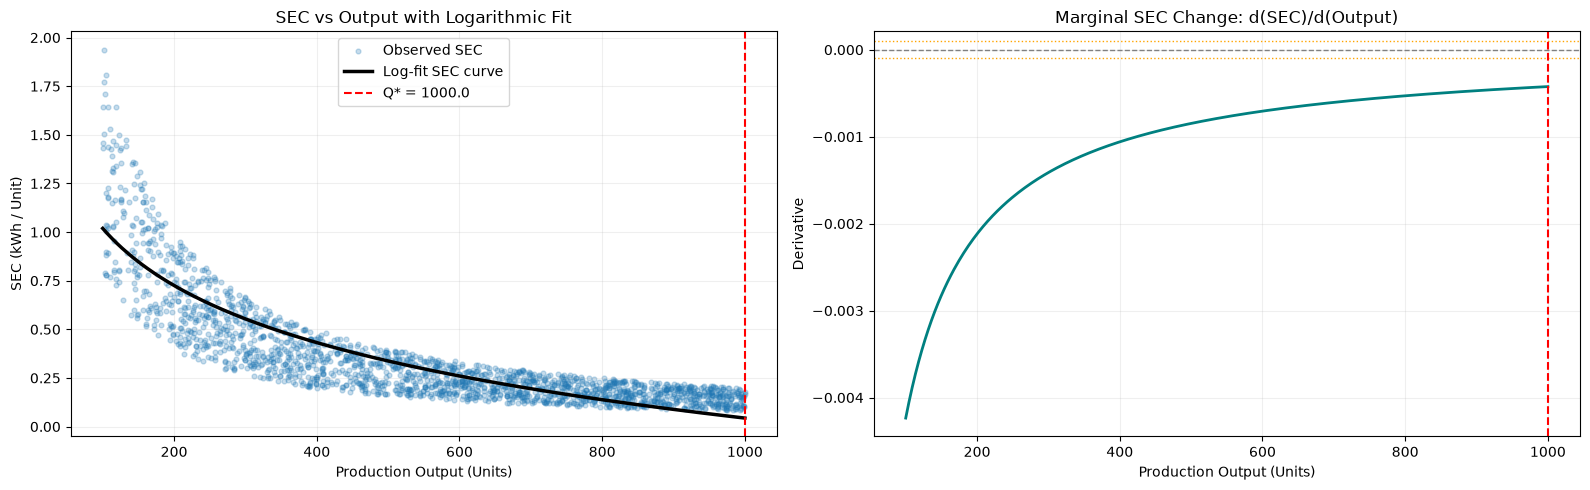

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from patsy import dmatrix

# 1) Variable formulation: SEC = Energy Consumption / Production Output.
sec_df = df.copy()
sec_df = sec_df.rename(
    columns={
        "Machine ID": "machine_id",
        "Quantity Used (kg)": "quantity_used_kg",
        "Energy Consumption (kWh)": "energy_kwh",
        "Production Output (Units)": "output_units",
    }
)

# Keep valid positive records for log and ratio operations.
sec_df = sec_df[(sec_df["energy_kwh"] > 0) & (sec_df["output_units"] > 0)].copy()
sec_df["sec"] = sec_df["energy_kwh"] / sec_df["output_units"]
sec_df["log_output"] = np.log(sec_df["output_units"])

print("Rows used:", len(sec_df))
print("SEC summary:")
print(sec_df["sec"].describe())

# 2) Model specifications.
# Baseline linear model in output.
linear_model = smf.ols(
    "sec ~ output_units + quantity_used_kg + C(machine_id)",
    data=sec_df,
).fit()

# Logarithmic model from the hypothesis equation.
log_model = smf.ols(
    "sec ~ log_output + quantity_used_kg + C(machine_id)",
    data=sec_df,
).fit()

# Polynomial model (quadratic in output).
poly_model = smf.ols(
    "sec ~ output_units + I(output_units**2) + quantity_used_kg + C(machine_id)",
    data=sec_df,
).fit()

# Piecewise linear spline model (3 internal knots at quartiles).
knots = sec_df["output_units"].quantile([0.25, 0.5, 0.75]).tolist()
spline_basis = dmatrix(
    "bs(output_units, knots=knots, degree=1, include_intercept=False)",
    {"output_units": sec_df["output_units"], "knots": knots},
    return_type="dataframe",
)
spline_cols = [f"spline_{i}" for i in range(spline_basis.shape[1])]
spline_basis.columns = spline_cols
spline_df = pd.concat([sec_df.reset_index(drop=True), spline_basis.reset_index(drop=True)], axis=1)
spline_formula = "sec ~ " + " + ".join(spline_cols) + " + quantity_used_kg + C(machine_id)"
spline_model = smf.ols(spline_formula, data=spline_df).fit()

print("\nModel fit metrics:")
print(
    pd.DataFrame(
        {
            "Model": ["Linear", "Log", "Polynomial", "Spline"],
            "R2": [linear_model.rsquared, log_model.rsquared, poly_model.rsquared, spline_model.rsquared],
            "Adj_R2": [
                linear_model.rsquared_adj,
                log_model.rsquared_adj,
                poly_model.rsquared_adj,
                spline_model.rsquared_adj,
            ],
            "AIC": [linear_model.aic, log_model.aic, poly_model.aic, spline_model.aic],
            "BIC": [linear_model.bic, log_model.bic, poly_model.bic, spline_model.bic],
        }
    ).round(4)
)

# 3) Hypothesis testing.
# (a) Direct t-test in the log model for H0: beta_log_output = 0.
print("\nLog-model coefficient test for H0: beta_log_output = 0")
print(log_model.summary().tables[1])

# (b) Model-comparison F-test: does log term improve fit over a linear output term?
f_stat, f_pvalue, f_df_diff = log_model.compare_f_test(linear_model)
print("\nF-test (log model vs linear-output model):")
print(f"F = {f_stat:.4f}, p-value = {f_pvalue:.6g}, df_diff = {f_df_diff:.0f}")

# 4) Optimization target: point of diminishing returns where d(SEC)/d(Output) ~ 0.
# For sec = b0 + b1*ln(output) + ... , derivative w.r.t. output is b1/output.
b1 = log_model.params.get("log_output", np.nan)
median_qty = float(sec_df["quantity_used_kg"].median())
ref_machine = sec_df["machine_id"].mode().iat[0]

x_grid = np.linspace(sec_df["output_units"].min(), sec_df["output_units"].max(), 400)
pred_grid = pd.DataFrame(
    {
        "output_units": x_grid,
        "log_output": np.log(x_grid),
        "quantity_used_kg": median_qty,
        "machine_id": ref_machine,
    }
)
pred_sec = log_model.predict(pred_grid)
derivative = b1 / x_grid

# Practical near-zero threshold for slope magnitude.
threshold = 1e-4
near_zero_idx = np.where(np.abs(derivative) <= threshold)[0]
if len(near_zero_idx) > 0:
    q_star = x_grid[near_zero_idx[0]]
else:
    q_star = x_grid[-1]

print("\nDiminishing-returns estimate:")
print(f"beta_log_output = {b1:.6f}")
print(f"First output where |dSEC/dOutput| <= {threshold}: Q* = {q_star:.2f} units")

# Visualization.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: data cloud + log-fit curve at reference controls.
sample_n = min(2000, len(sec_df))
plot_sample = sec_df.sample(sample_n, random_state=42)
axes[0].scatter(plot_sample["output_units"], plot_sample["sec"], alpha=0.25, s=12, label="Observed SEC")
axes[0].plot(x_grid, pred_sec, color="black", linewidth=2.5, label="Log-fit SEC curve")
axes[0].axvline(q_star, color="red", linestyle="--", linewidth=1.5, label=f"Q* = {q_star:.1f}")
axes[0].set_title("SEC vs Output with Logarithmic Fit")
axes[0].set_xlabel("Production Output (Units)")
axes[0].set_ylabel("SEC (kWh / Unit)")
axes[0].legend()
axes[0].grid(alpha=0.2)

# Right: derivative profile.
axes[1].plot(x_grid, derivative, color="teal", linewidth=2)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[1].axhline(threshold, color="orange", linestyle=":", linewidth=1)
axes[1].axhline(-threshold, color="orange", linestyle=":", linewidth=1)
axes[1].axvline(q_star, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Marginal SEC Change: d(SEC)/d(Output)")
axes[1].set_xlabel("Production Output (Units)")
axes[1].set_ylabel("Derivative")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

Spline diminishing-returns point (|dSEC/dOutput| <= 0.0001): Q* = 1000.00 units


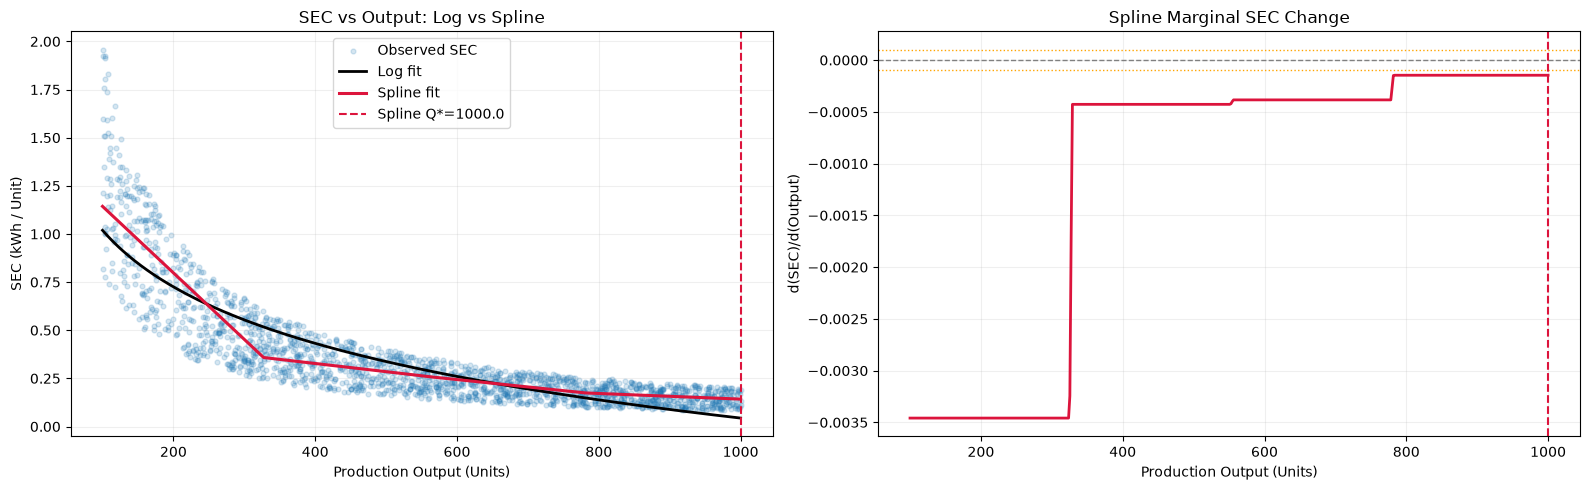

In [19]:
# Spline-focused visualization (recommended because spline had the best fit metrics).
# This uses the previously fitted models/variables from the SEC analysis cell.

# Prediction grid with fixed controls.
x_grid2 = np.linspace(sec_df["output_units"].min(), sec_df["output_units"].max(), 500)
median_qty2 = float(sec_df["quantity_used_kg"].median())
ref_machine2 = sec_df["machine_id"].mode().iat[0]

# Build spline basis on the same knot locations used in fitting.
spline_basis_grid = dmatrix(
    "bs(output_units, knots=knots, degree=1, include_intercept=False)",
    {"output_units": x_grid2, "knots": knots},
    return_type="dataframe",
)
spline_basis_grid.columns = spline_cols

pred_spline_df = pd.DataFrame(spline_basis_grid)
pred_spline_df["quantity_used_kg"] = median_qty2
pred_spline_df["machine_id"] = ref_machine2

pred_log_df = pd.DataFrame(
    {
        "output_units": x_grid2,
        "log_output": np.log(x_grid2),
        "quantity_used_kg": median_qty2,
        "machine_id": ref_machine2,
    }
)

spline_pred = spline_model.predict(pred_spline_df)
log_pred = log_model.predict(pred_log_df)

# Numerical derivative of the spline fitted curve.
spline_derivative = np.gradient(spline_pred, x_grid2)

# Near-flat threshold for diminishing returns.
spline_threshold = 1e-4
flat_idx = np.where(np.abs(spline_derivative) <= spline_threshold)[0]
if len(flat_idx) > 0:
    q_star_spline = x_grid2[flat_idx[0]]
else:
    q_star_spline = x_grid2[-1]

print(f"Spline diminishing-returns point (|dSEC/dOutput| <= {spline_threshold}): Q* = {q_star_spline:.2f} units")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: compare spline vs log fit.
sample_n2 = min(2000, len(sec_df))
plot_sample2 = sec_df.sample(sample_n2, random_state=7)
axes[0].scatter(plot_sample2["output_units"], plot_sample2["sec"], alpha=0.18, s=12, label="Observed SEC")
axes[0].plot(x_grid2, log_pred, color="black", linewidth=2, label="Log fit")
axes[0].plot(x_grid2, spline_pred, color="crimson", linewidth=2.2, label="Spline fit")
axes[0].axvline(q_star_spline, color="crimson", linestyle="--", linewidth=1.5, label=f"Spline Q*={q_star_spline:.1f}")
axes[0].set_title("SEC vs Output: Log vs Spline")
axes[0].set_xlabel("Production Output (Units)")
axes[0].set_ylabel("SEC (kWh / Unit)")
axes[0].legend()
axes[0].grid(alpha=0.2)

# Right: spline marginal effect profile.
axes[1].plot(x_grid2, spline_derivative, color="crimson", linewidth=2)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[1].axhline(spline_threshold, color="orange", linestyle=":", linewidth=1)
axes[1].axhline(-spline_threshold, color="orange", linestyle=":", linewidth=1)
axes[1].axvline(q_star_spline, color="crimson", linestyle="--", linewidth=1.5)
axes[1].set_title("Spline Marginal SEC Change")
axes[1].set_xlabel("Production Output (Units)")
axes[1].set_ylabel("d(SEC)/d(Output)")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

We conclude that the Specific Energy Consumption (SEC) ($\text{kWh/Unit}$) decays non-linearly as run volume increases. Small batches are energy-inefficient.

## Hypothesis 3: Recycled Material Impurity Variance Drives Quality Degradation

Hypothesis ($H_3$): Increasing the proportion of recycled content (Recycled Material (%)) beyond a critical threshold $\theta^*$ causes a non-linear jump in Defect Rate (%).

This establishes the precise trade-off limit between sustainability goals (ESG targets) and scrap costs.


* We first filter for batches where $\text{Recycled Material (\%)} > 0$ (e.g., Reprocessed Plastics, Scrap Steel).
* Fit a piecewise linear regression model with an unknown knot $\theta^*$:

$$\text{Defect Rate}_i = \begin{cases} \beta_0 + \beta_1 R_i + \epsilon_i & \text{if } R_i \le \theta^* \\ \beta_0 + \beta_1 R_i + \beta_2 (R_i - \theta^*) + \epsilon_i & \text{if } R_i > \theta^* \end{cases}$$

Where $R_i$ is Recycled Material (%).

* Lastly, perform a Davies Test to determine if the change in slope ($\beta_2$) after the threshold $\theta^*$ is statistically significant.

Rows with recycled content > 0: 1618
       recycled_pct  defect_rate_pct
count   1618.000000      1618.000000
mean      25.095087         2.524116
std       14.411292         1.419784
min        0.100000         0.000000
25%       12.580000         1.280000
50%       25.230000         2.540000
75%       37.767500         3.710000
max       49.960000         5.000000

Best threshold by AIC (theta*): 18.48
Best segmented model coefficients:
recycled_pct       -0.007911
hinge               0.010599
quantity_used_kg    0.000398
dtype: float64

Fixed-theta nested F-test (best segmented vs null):
F = 0.9445, p-value = 0.331277, df_diff = 1

Davies-style supremum test (bootstrap approximation):
Observed sup |t| = 0.9718
Bootstrap p-value = 0.783333 (B=120)


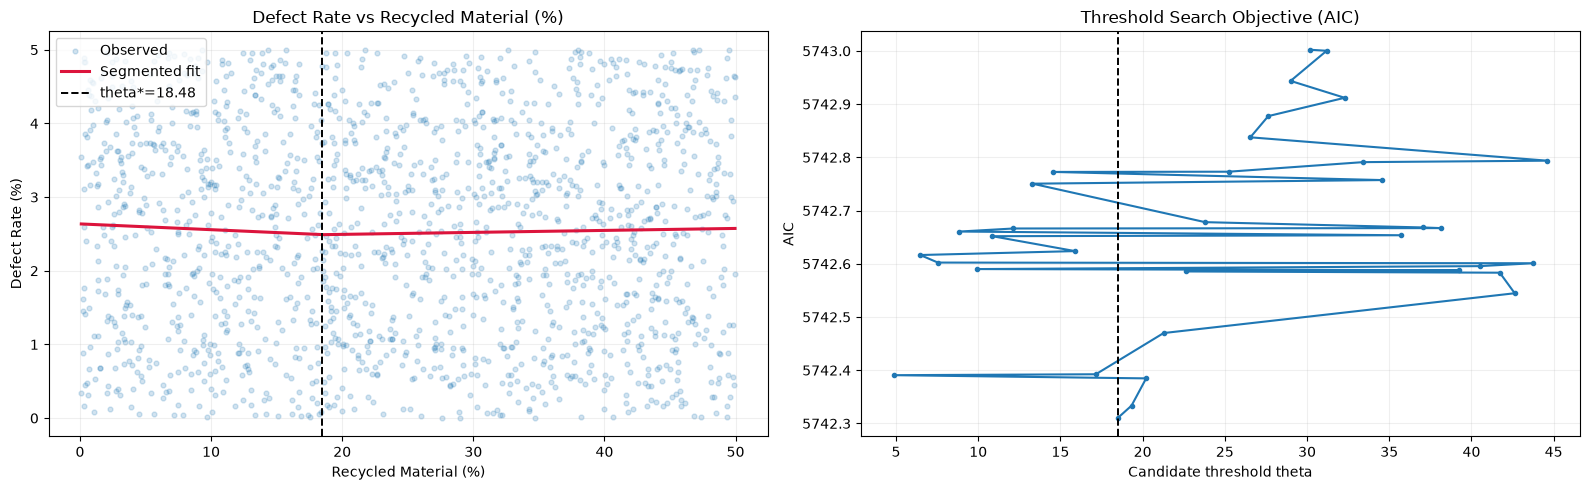

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# 1) Dataset subsetting: only rows with recycled content > 0.
h3_df = df.copy().rename(
    columns={
        "Recycled Material (%)": "recycled_pct",
        "Defect Rate (%)": "defect_rate_pct",
        "Quantity Used (kg)": "quantity_used_kg",
        "Machine ID": "machine_id",
    }
)
h3_df = h3_df[(h3_df["recycled_pct"] > 0) & h3_df["defect_rate_pct"].notna()].copy()

print("Rows with recycled content > 0:", len(h3_df))
print(h3_df[["recycled_pct", "defect_rate_pct"]].describe())

# Candidate thresholds (exclude extremes for stable segment estimation).
theta_grid = np.quantile(h3_df["recycled_pct"], np.linspace(0.10, 0.90, 35))
theta_grid = np.unique(np.round(theta_grid, 6))

# Null model (no breakpoint term).
null_model = smf.ols(
    "defect_rate_pct ~ recycled_pct + quantity_used_kg + C(machine_id)",
    data=h3_df,
).fit()

# Fit segmented model for each candidate threshold and keep diagnostics.
seg_results = []
for theta in theta_grid:
    temp = h3_df.copy()
    temp["hinge"] = np.maximum(0.0, temp["recycled_pct"] - theta)
    alt = smf.ols(
        "defect_rate_pct ~ recycled_pct + hinge + quantity_used_kg + C(machine_id)",
        data=temp,
    ).fit()
    seg_results.append(
        {
            "theta": theta,
            "aic": alt.aic,
            "bic": alt.bic,
            "rss": float(np.sum(alt.resid ** 2)),
            "hinge_coef": alt.params.get("hinge", np.nan),
            "hinge_t": alt.tvalues.get("hinge", np.nan),
            "model": alt,
        }
    )

seg_df = pd.DataFrame(seg_results).sort_values("aic").reset_index(drop=True)
best_theta = float(seg_df.loc[0, "theta"])
best_model = seg_df.loc[0, "model"]

print("\nBest threshold by AIC (theta*):", round(best_theta, 4))
print("Best segmented model coefficients:")
print(best_model.params[["recycled_pct", "hinge", "quantity_used_kg"]])

# Standard fixed-theta nested F-test versus null.
f_stat, f_pvalue, f_df_diff = best_model.compare_f_test(null_model)
print("\nFixed-theta nested F-test (best segmented vs null):")
print(f"F = {f_stat:.4f}, p-value = {f_pvalue:.6g}, df_diff = {f_df_diff:.0f}")

# 3) Davies-style test for unknown breakpoint:
# Supremum of |t_hinge(theta)| over theta, with bootstrap p-value under null.
obs_sup_t = np.nanmax(np.abs(seg_df["hinge_t"].values))

rng = np.random.default_rng(42)
B = 120  # Increase to 300+ for a tighter p-value estimate.
resid_null = null_model.resid.values
fitted_null = null_model.fittedvalues.values

def sup_t_for_sample(y_star):
    work = h3_df.copy()
    work["y_star"] = y_star
    sup_t = -np.inf
    for theta in theta_grid:
        work["hinge"] = np.maximum(0.0, work["recycled_pct"] - theta)
        m = smf.ols(
            "y_star ~ recycled_pct + hinge + quantity_used_kg + C(machine_id)",
            data=work,
        ).fit()
        t_val = np.abs(m.tvalues.get("hinge", np.nan))
        if np.isfinite(t_val) and t_val > sup_t:
            sup_t = t_val
    return sup_t

boot_sup_t = np.empty(B)
resid_centered = resid_null - resid_null.mean()

for b in range(B):
    sampled_resid = rng.choice(resid_centered, size=len(resid_centered), replace=True)
    y_star = fitted_null + sampled_resid
    boot_sup_t[b] = sup_t_for_sample(y_star)

davies_p = float(np.mean(boot_sup_t >= obs_sup_t))
print("\nDavies-style supremum test (bootstrap approximation):")
print(f"Observed sup |t| = {obs_sup_t:.4f}")
print(f"Bootstrap p-value = {davies_p:.6g} (B={B})")

# Visualization: data, segmented fit at reference controls, and objective curve over theta.
x_grid3 = np.linspace(h3_df["recycled_pct"].min(), h3_df["recycled_pct"].max(), 400)
median_qty3 = float(h3_df["quantity_used_kg"].median())
ref_machine3 = h3_df["machine_id"].mode().iat[0]

pred3 = pd.DataFrame(
    {
        "recycled_pct": x_grid3,
        "hinge": np.maximum(0.0, x_grid3 - best_theta),
        "quantity_used_kg": median_qty3,
        "machine_id": ref_machine3,
    }
)
seg_fit_line = best_model.predict(pred3)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sample_n3 = min(2500, len(h3_df))
plot3 = h3_df.sample(sample_n3, random_state=42)
axes[0].scatter(plot3["recycled_pct"], plot3["defect_rate_pct"], alpha=0.2, s=12, label="Observed")
axes[0].plot(x_grid3, seg_fit_line, color="crimson", linewidth=2.2, label="Segmented fit")
axes[0].axvline(best_theta, color="black", linestyle="--", linewidth=1.4, label=f"theta*={best_theta:.2f}")
axes[0].set_title("Defect Rate vs Recycled Material (%)")
axes[0].set_xlabel("Recycled Material (%)")
axes[0].set_ylabel("Defect Rate (%)")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(seg_df["theta"], seg_df["aic"], marker="o", markersize=3)
axes[1].axvline(best_theta, color="black", linestyle="--", linewidth=1.4)
axes[1].set_title("Threshold Search Objective (AIC)")
axes[1].set_xlabel("Candidate threshold theta")
axes[1].set_ylabel("AIC")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

Since $p > 5%$ we fail to reject $H_0$. We can conclude that the recycled content does not significantly degrade quality; set blending limits solely based on raw material availability or external customer specs.

## Hypothesis 4: Machine Efficiency Heterogeneity (Unrelated Parallel Machines)

Hypothesis ($H_4$): Machine variance accounts for more variance in energy consumption and defect rates than material type, proving machines behave as Unrelated Parallel Machines rather than Identical Parallel Machines.

This will dictate whether scheduling models can treat machines as interchangeable or require machine-specific performance coefficients.

* We first fit a Hierarchical Linear Model (HLM) / Mixed-Effects Model:
    $$\text{Energy}_i = \mu + \alpha_{\text{Material}} + \gamma_{\text{Machine}} + \epsilon_i$$
    
    Where $\alpha_{\text{Material}}$ is a fixed effect and $\gamma_{\text{Machine}}$ is a random effect.
* Then calculate the Intraclass Correlation Coefficient (ICC) to quantify the proportion of total variance explained by machine-level differences vs. material selection.

* Then conduct Tukey’s HSD test on estimated marginal means across M001 through M010 to rank machine efficiencies.

Rows used for H4: 10000
Machines present: ['M001', 'M002', 'M003', 'M004', 'M005', 'M006', 'M007', 'M008', 'M009', 'M010']


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(



Mixed-effects model summary:
                           Mixed Linear Model Regression Results
Model:                         MixedLM            Dependent Variable:            energy_kwh 
No. Observations:              10000              Method:                        REML       
No. Groups:                    10                 Scale:                         1191.8817  
Min. group size:               964                Log-Likelihood:                -49600.5242
Max. group size:               1041               Converged:                     Yes        
Mean group size:               1000.0                                                       
--------------------------------------------------------------------------------------------
                                               Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
--------------------------------------------------------------------------------------------
Intercept                                     140.199    0.878 159.6

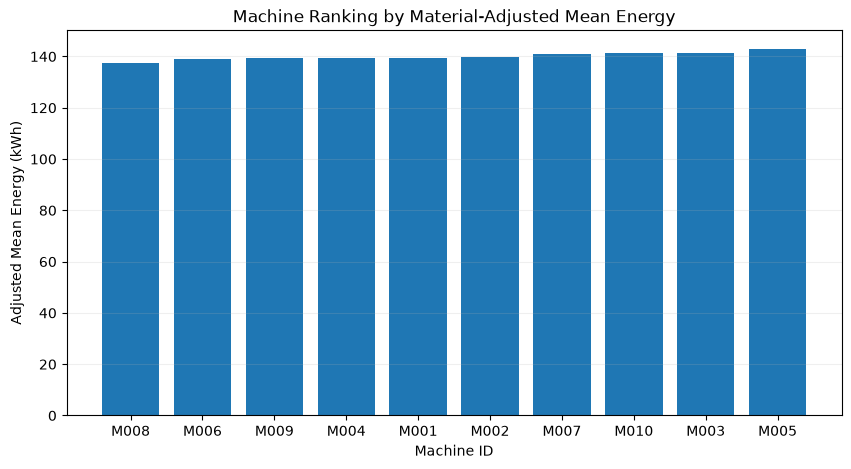

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Prepare data for H4.
h4_df = df.copy().rename(
    columns={
        "Energy Consumption (kWh)": "energy_kwh",
        "Material Category": "material_category",
        "Machine ID": "machine_id",
    }
)
h4_df = h4_df[["energy_kwh", "material_category", "machine_id"]].dropna().copy()

# Keep only M001..M010 as requested.
valid_machines = [f"M{idx:03d}" for idx in range(1, 11)]
h4_df = h4_df[h4_df["machine_id"].isin(valid_machines)].copy()

print("Rows used for H4:", len(h4_df))
print("Machines present:", sorted(h4_df["machine_id"].unique()))

# 1) Variance decomposition via mixed-effects model.
# Energy_i = mu + alpha_material + gamma_machine + epsilon_i
h4_mixed = smf.mixedlm(
    "energy_kwh ~ C(material_category)",
    data=h4_df,
    groups=h4_df["machine_id"],
).fit(reml=True)

print("\nMixed-effects model summary:")
print(h4_mixed.summary())

# 2) ICC = var(machine random intercept) / total variance.
var_machine = float(h4_mixed.cov_re.iloc[0, 0])
var_resid = float(h4_mixed.scale)
icc = var_machine / (var_machine + var_resid)

print("\nVariance decomposition:")
print(f"Machine-level variance (random intercept): {var_machine:.6f}")
print(f"Residual variance: {var_resid:.6f}")
print(f"ICC (machine share of variance): {icc:.4f}")

# 3) Post-hoc Tukey HSD on material-adjusted machine effects.
# Remove fixed material effects first, then compare machine means.
h4_material_ols = smf.ols("energy_kwh ~ C(material_category)", data=h4_df).fit()
grand_mean = float(h4_df["energy_kwh"].mean())

# Adjusted response that keeps overall level but removes material differences.
h4_df["energy_adj"] = grand_mean + h4_material_ols.resid

tukey = pairwise_tukeyhsd(
    endog=h4_df["energy_adj"],
    groups=h4_df["machine_id"],
    alpha=0.05,
)

print("\nTukey HSD on material-adjusted machine means:")
print(tukey.summary())

# Machine ranking by adjusted mean energy (lower is more efficient).
rank_df = (
    h4_df.groupby("machine_id", as_index=False)["energy_adj"]
    .mean()
    .rename(columns={"energy_adj": "adj_mean_energy_kwh"})
    .sort_values("adj_mean_energy_kwh", ascending=True)
)
rank_df["efficiency_rank"] = np.arange(1, len(rank_df) + 1)

print("\nMachine efficiency ranking (1 = most energy-efficient):")
print(rank_df)

# Visualization: adjusted mean energy by machine.
plt.figure(figsize=(10, 5))
plt.bar(rank_df["machine_id"], rank_df["adj_mean_energy_kwh"])
plt.title("Machine Ranking by Material-Adjusted Mean Energy")
plt.xlabel("Machine ID")
plt.ylabel("Adjusted Mean Energy (kWh)")
plt.grid(axis="y", alpha=0.2)
plt.show()

We therefore conclude that the machines are Identical Parallel Machines. Parameters simplify to $p_j, e_j, d_j$, drastically reducing model dimensionality.